# BEE 4750 Homework 4: Monte Carlo, Uncertainty, and Risk

**Name**: Mikael Murphy-Rendon

**ID**:mm3446

> **Due Date**
>
> Thursday, 10/08/26, 9:00pm

## Overview

### Instructions

- Problem 1 consists of problems that should be solved by hand:
  expectations, Monte Carlo error, and return periods.
- Problem 2 is a short computational Monte Carlo analysis: propagate a
  flood hazard distribution through a depth-damage function.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [99]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/hw04`


In [100]:
using Random
using Distributions
using Statistics
using Plots

## Problems (Total: 50 Points)

### Problem 1 (30 points)

#### Problem 1.1 (8 points)

A treatment unit removes a fraction $R$ of the incoming load, where $R$
is uncertain with mean $\mathbb{E}[R] = 0.6$ and variance
$\text{Var}(R) = 0.01$. The incoming load is a known constant $B_0 = 50$
mg/L, so the load leaving the unit is $Y = B_0(1 - R)$.

1.  Find $\mathbb{E}[Y]$ and $\text{Var}(Y)$.

2.  Now suppose the quantity you care about is the square of the
    outgoing load, $Z = Y^2$. Is $\mathbb{E}[Z]$ equal to
    $\left(\mathbb{E}[Y]\right)^2$? Compute both and state the
    difference.

3.  In one or two sentences, explain what this implies about running an
    environmental model once at the mean value of an uncertain input.


#### Problem 1.2 (7 points)

You are estimating a probability by Monte Carlo. With $n = 2,000$
samples your estimate is $\hat{p} = 0.08$ and the standard error is
$0.006$.

1.  Write down the 95% confidence interval.

2.  You need the standard error to be no larger than $0.002$. How many
    samples will that take?

3.  A colleague proposes reducing your error instead by using a finer
    spatial grid in the underlying simulation. Will that help with
    *this* source of error? Explain.

#### Problem 1.3 (7 points)

A pump station is designed against the 50-year flood.

1.  What annual exceedance probability does that correspond to?

2.  The station has a 20-year service life. Assuming years are
    independent, write the expression for the probability that it is
    overtopped at least once during that life. You do not need to
    evaluate it.

3.  Your client says: “the station was overtopped last year, so we have
    another 49 years before it happens again.” Explain what is wrong
    with this.

#### Problem 1.4 (8 points)

Classify each of the following as primarily **aleatory** or primarily
**epistemic** uncertainty, and justify each in one sentence.

1.  The daily variation in influent flow to a treatment plant.
2.  The strength of the ice-albedo feedback.
3.  The rate of sediment recycling in a shallow lake.
4.  Which of next year’s storms will be the largest.

#### Answer 1.1
1. 
$$
\begin{array}{lll}
E[R]=0.6 & B_0=50 \mathrm{mg} / \mathrm{L} & \text { incoming } \\
\operatorname{Var}(R)=0.01 & Y=B_0(1-R) & \text { leaving }
\end{array}
$$

$$
\begin{aligned}
E[Y]=E\left[B_0(1-R)\right]=E[B_0]-E\left[B_0 R\right] & =B_0-B_0 E(R) \\
& =50-50(0.6) \\
& =20 \mathrm{mg} / \mathrm{L}
\end{aligned}
$$

$$
\begin{aligned}
\operatorname{Var}(Y)=B_0^2\operatorname{Var}\left((1-R)\right]=B_0^2 \operatorname{Var}(R) =2500.0 *0.01 =25 \mathrm{mg^2} / \mathrm{L^2}
\end{aligned}
$$

2. 
$$
\begin{aligned}
& Z=Y^2 \\
& (E[Y])^2=20^2=400(\mathrm{mg} / \mathrm{L})^2 \\
& E[Z]=E\left[Y^2\right]=\operatorname{Var}(Y)+(E[Y])^2= 25+400=425(\mathrm{mg} / \mathrm{L})^2 \\
& E[Z]-(E[Y])^2=25(\mathrm{mg} / \mathrm{L})^2
\end{aligned}
$$

3. Running a non-linear model (most environmental models) based only on the mean value of an uncertain input will generate bias and misestimate the true $E[X]$. This is because Z is a non-linear transformation of Y, which was a linear transformation of R, so E[f(X)] does not need to equal f(E[X]).

#### Answer 1.2
1. 
$$
\begin{array}{ll}
n=2,000 \quad \hat{p}=0.08 \quad & \sigma_n =0.006 \\
& \sigma_n =\sigma_y / \sqrt{n}=\sqrt{\operatorname{Var}\left(Y_i\right)} / \sqrt{n}
\end{array}
$$
$$
\begin{aligned}
& 95 \% CI: \tilde{\mu}_n \pm 1.96 \frac{\sigma_y}{\sqrt{n}} \\
& 0.08 \pm 1.96(0.006) \\
& C I:[0.06824,0.09176]
\end{aligned}
$$
2. 
Monte Carlo simulation errors decrease as $1 / \sqrt{n}$
$$
\begin{aligned}
& \sigma=0.006 \rightarrow 0.002=\frac{1}{3} \sigma \\
& \frac{1}{\sqrt{n}}=\frac{1}{3} \rightarrow \sqrt{n}=3 \quad n_{new}=n*9\\
& n_{\text {new }}=18,000 \ \text { samples}
\end{aligned}
$$
3. No, that will not help with *this* source of error because the standard measures sampling error from a finite sample statistics to estimate a population statistic. A grid change would impact only the discretization error and not the underlying stochastic processes that determine the sampling error.

#### Answer 1.3
1. 
$$
\begin{aligned}
& T=1 / p \\
& \text { so }=1 / p \quad p=0.02 \rightarrow 2 \% \text { exceedance probability }
\end{aligned}
$$
2. 
$$1-(1-0.02)^{20}$$
3. This is the gambler's fallacy -> an X-year flood standard is defined as the 1/X chance of failure in any given year, not that there is a guaranteed failure once in the X-year period. Here, every single year, there is a 2% chance of overtopping because each year is independent from the last and uses the same annual exceedance probability.

#### Answer 1.4
1. Aleatory - there is a natural randomness in both weather patterns \& human use of waste disposal systems.
2. Epistemic - there is a current lack of knowledge on climate behavior that can be addressed with further study.
3. Epistemic - uncertainty in the model parameters come from imperfect measurement which be improved with sampling to reduce error.
4. Aleatory - there are natural stochastic variation \& chaotic atmospheric physics that determine the actual systems behavior.


### Problem 2 (20 points)

Flood risk is usually quantified by propagating a distribution of flood
depths through a depth-damage function, which converts a flood depth
into an economic loss. A common form for a house without a basement is a
bounded logistic curve,

$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp\left(-k(h - h_0)\right)},$$

where $h$ is the flood depth in metres and $d$ is the damage in dollars.
We’ll use $L = \$200,000$, $k = 0.8$, and $h_0 = 3$ in our depth-damage
function specification.

Assume the annual maximum flood depth at this structure is distributed
as

$$h \sim \text{LogNormal}(1.2,\ 0.3).$$

#### Problem 2.1 (5 points)

Implement the depth-damage function and plot it over depths from 0 to
8m. On a second panel, plot the density of the hazard distribution over
the same range.

Looking at the two panels together: over what range of depths does a
small change in depth produce the largest change in damage?

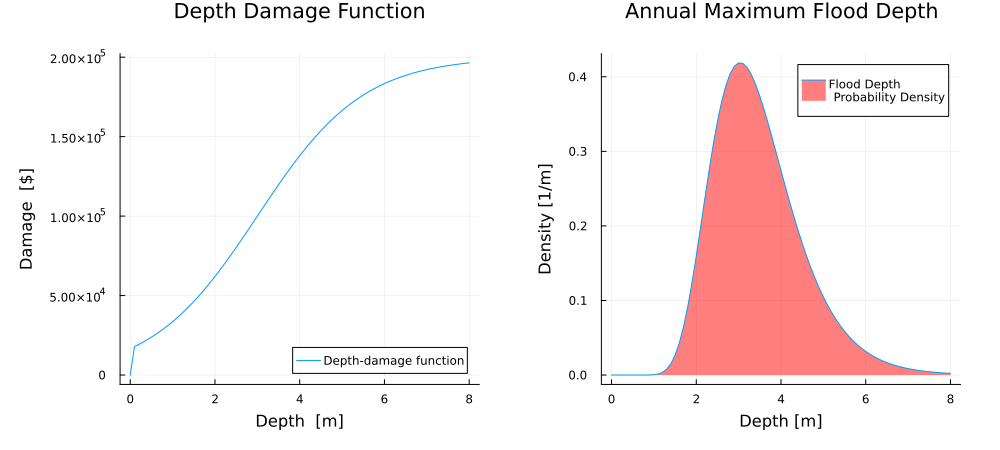

In [101]:
function depth_damage(depth)
    L = 200000
    k = 0.8
    h0 = 3

    if depth>0 
        damage = L/(1+exp(-k*(depth-h0)))
    else
        damage = 0
    end
    return damage
end

x=0:0.1:8
P_damage = plot(x,depth_damage.(0:0.1:8),label="Depth-damage function")
plot!(P_damage,title="Depth Damage Function",xlabel="Depth  [m]", ylabel="Damage  [\$]", legend=:bottomright)

d = LogNormal(1.2,0.3)
P_dist = plot(x, pdf.(d,x), fill=(0, 0.5, :red),label="Flood Depth \n Probability Density")
plot!(P_dist,title="Annual Maximum Flood Depth", xlabel="Depth [m]", ylabel="Density [1/m]",legend=:topright)

plot(P_damage, P_dist, layout = (1, 2), size=(1000, 450), margin=8Plots.mm)

#### Answer 2.1
I made a basic function that checks if the water depth is greater than 0 and then uses the given bounded logistic curve to calculate damage. From this, I plotted the damage-depth function from a depth of 0m to 8m with a step size of 0.1 m to see the logistic curve. Next to this plot, I also graphed the lognormal probability density function from the same range.

The slope of the logistic curve is steepest around 2 to 4 meters (specifically with an inflection point at 3 since $h_0$= 3), so this would produce the largest change in damage for a small change in depth. 

#### Problem 2.2 (8 points)

Estimate the expected annual damage using Monte Carlo.

Report your estimate, a 95% confidence interval, the sample size you
used, and the seed you set. Then justify the sample size by doubling it
and comparing the estimates.

In [102]:
Random.seed!(24)
n=10000
rand_depths = rand(d,2n)
rand_damages = depth_damage.(rand_depths)

for i in (n, 2n)
    sample = rand_damages[1:i]
    estimate = mean(sample)
    st_err = std(sample)/sqrt(i)
    ci_95 = (estimate - 1.96*st_err, estimate + 1.96*st_err)

    println("n = $i")
    println("Monte Carlo SE = \$", round(st_err;digits=2))
    println("Estimated expected annual damage = \$", round(estimate; digits=2))
    println("95% confidence interval = ", round.(ci_95; digits=2))
end

n = 10000
Monte Carlo SE = $340.18
Estimated expected annual damage = $114804.92
95% confidence interval = (114138.16, 115471.67)
n = 20000
Monte Carlo SE = $243.13
Estimated expected annual damage = $115267.75
95% confidence interval = (114791.21, 115744.29)


#### Answer 2.2
For the Monte Carlo simulation I drew the annual depths from the provided LogNormal distribution, applied the depth-damage function to each sample, and averaged the resulting damage estimates. I used a seed of 24.<br>

n = 10000<br>
Monte Carlo SE = $\$$ 340.18<br>
Estimated expected annual damage = $\$$ 114804.92<br>
95% confidence interval = (114138.16, 115471.67)<br>

n = 20000<br>
Monte Carlo SE = $\$$ 243.13<br>
Estimated expected annual damage = $\$$ 115267.75<br>
95% confidence interval = (114791.21, 115744.29)<br>

The relative difference between the two estimates was only 0.403%, so I argue that the original sample size of 10000 is enough to estimate the expected annual damage.

#### Problem 2.3 (7 points)

1.  Now estimate the 99th percentile of annual damage. How much larger
    is this than the mean?

2.  For the same number of samples, your estimate of the 99th percentile
    is less precise than your estimate of the mean. Explain why.

3.  Your analysis produces a distribution of *damages*, not a
    distribution of *depths*. In one or two sentences, explain why just
    modeling depth does not fully capture risk, and identify which
    component of risk the depth-damage function represents. Is anything
    missing from this as a **risk analysis**?

In [103]:
Random.seed!(24)
rand_damages=depth_damage.(rand(d,n))
q_99 = quantile(rand_damages,0.99)
mean_damage = mean(rand_damages)

println("99th-percentile annual damage: \$", round(q_99; digits=2))
println("Mean annual damage: \$", round(mean_damage; digits=2))
println("Difference: \$", round(q_99 - mean_damage; digits=2))
println("Ratio: ", round(q_99 / mean_damage; digits=2))

99th-percentile annual damage: $189789.72
Mean annual damage: $114804.92
Difference: $74984.8
Ratio: 1.65


#### Answer 2.3
1. 99th-percentile annual damage: $\$$ 189789.72. This is 1.65 times as large as the mean (difference of $\$$ 74984.8).
2. The 99-th percentile is estimated from the upper tail (0.01n --> 100 observations). Only 100/10,000 observations provide minimal information as any extreme observation can shift the estimate due to the lognormal distribution's sensitivity to extreme values. On the other hand, the mean uses all 10,000 observations, so it will be more accurate.
3. Only modeling the depth does not fully capture the risk of the flooding hazard because it does not consider the actual economic impact on a given house. The depth-damage function represents the vulnerability. This risk analysis is missing components like the amount of time the home stays inundated, if there are living beings present, different asset classes present, and the actual uncertainty of the given parameters L, k and $h_0$

## References

List any external references consulted, including classmates.
- Gina Chen
- 1.1, ECON 3310(Probability & Statistics) class notes